In [2]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

In [3]:
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [4]:
DEVICE = torch.device("cuda") 

IMG_DIR = "dataset/ISIC2018_Task3_Training_Input"
CSV_DIR = "dataset/ISIC2018_Task3_Training_GroundTruth/ISIC2018_Task3_Training_GroundTruth.csv"
df = pd.read_csv(CSV_DIR)

In [5]:
print(df.columns)
print(df.head(10))
label_cols = df.columns[1:]
df['label'] = df[label_cols].values.argmax(axis=1)

print("Classes:", list(label_cols))
print(df.head(10))

Index(['image', 'MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC'], dtype='str')
          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0
5  ISIC_0024311  0.0  1.0  0.0    0.0  0.0  0.0   0.0
6  ISIC_0024312  0.0  0.0  0.0    0.0  1.0  0.0   0.0
7  ISIC_0024313  1.0  0.0  0.0    0.0  0.0  0.0   0.0
8  ISIC_0024314  0.0  1.0  0.0    0.0  0.0  0.0   0.0
9  ISIC_0024315  1.0  0.0  0.0    0.0  0.0  0.0   0.0
Classes: ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC  label
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0      1
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0      1
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0      1
3  ISIC_0024309  0.0  

In [6]:
train_df, val_df = train_test_split(
    df, 
    test_size=0.20, 
    random_state=42, 
    stratify=df['label'] 
)

class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = [class_weights[t] for t in train_df['label']]

sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

In [7]:
class ISICDataset(Dataset):
    def __init__(self, df, img_dir, transform = None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_name = row['image']
        label = int(row['label'])

        img_path = os.path.join(self.img_dir, img_name + ".jpg")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])
    ])


val_transforms = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [9]:
BATCH_SIZE = 64
EPOCHS = 40

train_ds = ISICDataset(train_df, IMG_DIR, transform=train_transforms)
val_ds = ISICDataset(val_df, IMG_DIR, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
model = models.resnet50(weights = 'ResNet50_Weights.DEFAULT')

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer2.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 7)
)

In [11]:
model = model.to(DEVICE)

optimizer = torch.optim.AdamW([
    #{'params': model.layer2.parameters(), 'lr': 1e-5},
    {'params': model.layer3.parameters(), 'lr': 0.000003},
    {'params': model.layer4.parameters(), 'lr': 0.00003},
    {'params': model.fc.parameters(),     'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

In [12]:
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super(WeightedFocalLoss, self).__init__()
        self.alpha = alpha # This will be your class_weights
        self.gamma = gamma

    def forward(self, inputs, targets):
        # Calculate standard cross entropy with reduction='none' to keep per-sample loss
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        
        # Calculate the probability of the correct class
        pt = torch.exp(-ce_loss)
        
        # Apply the focal modulation factor
        focal_loss = (1 - pt)**self.gamma * ce_loss
        
        return focal_loss.mean()

# Define weights (MEL=2.5, AKIEC=2.5)
class_weights = torch.tensor([2.5, 1.0, 1.5, 2.5, 1.2, 2.0, 1.0]).to(DEVICE)
criterion = WeightedFocalLoss(alpha=class_weights, gamma=2)

In [12]:
best_val_accuracy = 0

early_stop_patience = 8
early_stop_counter = 0
best_val_loss = float('inf')

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    accuracy = correct / total
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {running_loss/len(train_loader):.4f} Acc: {accuracy:.4f}")

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            batch_loss = criterion(outputs, labels)
            val_running_loss += batch_loss.item()
            
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_accuracy = val_correct / val_total
    avg_val_loss = val_running_loss / len(val_loader)
    scheduler.step(avg_val_loss)
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        print(f"EarlyStopping counter: {early_stop_counter} out of {early_stop_patience}")

    if early_stop_counter >= early_stop_patience:
        print("#### Early Stopping Triggered ####")
        break

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}] Val-Loss: {avg_val_loss:.4f} Acc: {val_accuracy:.4f} LR: {current_lr}") 

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), f"{best_val_accuracy}.pth")
        print(f"--> Saved better model with Accuracy: {val_accuracy:.4f}")

print("#### Training Done ####")

Epoch [1/40] Loss: 2.3847 Acc: 0.3020
Epoch [1] Val-Loss: 1.5272 Acc: 0.2831 LR: 3e-06
--> Saved better model with Accuracy: 0.2831
Epoch [2/40] Loss: 1.2902 Acc: 0.6070
Epoch [2] Val-Loss: 1.0169 Acc: 0.5442 LR: 3e-06
--> Saved better model with Accuracy: 0.5442
Epoch [3/40] Loss: 0.8130 Acc: 0.7345
Epoch [3] Val-Loss: 0.8083 Acc: 0.6101 LR: 3e-06
--> Saved better model with Accuracy: 0.6101
Epoch [4/40] Loss: 0.6446 Acc: 0.7808
Epoch [4] Val-Loss: 0.7006 Acc: 0.6360 LR: 3e-06
--> Saved better model with Accuracy: 0.6360
Epoch [5/40] Loss: 0.5281 Acc: 0.8128
Epoch [5] Val-Loss: 0.6467 Acc: 0.6665 LR: 3e-06
--> Saved better model with Accuracy: 0.6665
Epoch [6/40] Loss: 0.4438 Acc: 0.8324
Epoch [6] Val-Loss: 0.5647 Acc: 0.6760 LR: 3e-06
--> Saved better model with Accuracy: 0.6760
Epoch [7/40] Loss: 0.3926 Acc: 0.8444
Epoch [7] Val-Loss: 0.5400 Acc: 0.6715 LR: 3e-06
Epoch [8/40] Loss: 0.3473 Acc: 0.8637
Epoch [8] Val-Loss: 0.4707 Acc: 0.7284 LR: 3e-06
--> Saved better model with Accura

In [13]:
def run_final_evaluation(model, loader, device, target_names):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    print("Collecting model predictions...")
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            
            # Get probabilities (for AUC) and class predictions (for F1/Confusion Matrix)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # 1. Calculate F1-Score (Weighted is best for imbalanced medical data)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    # 2. Calculate AUC (One-Vs-Rest for multi-class)
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')

    print(f"\n--- PERFORMANCE SUMMARY ---")
    print(f"Weighted F1-Score: {f1:.4f}")
    print(f"Weighted AUC:      {auc:.4f}")
    print(f"---------------------------\n")
    
    # 3. Print Detailed Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # 4. Generate and Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.title(f'Confusion Matrix (F1: {f1:.3f})', fontsize=15)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

    return f1, auc


--- PERFORMANCE SUMMARY ---
Weighted F1-Score: 0.8710
Weighted AUC:      0.9689
---------------------------

Classification Report:
              precision    recall  f1-score   support

         MEL       0.64      0.73      0.68       223
          NV       0.95      0.91      0.93      1341
         BCC       0.77      0.93      0.85       103
       AKIEC       0.64      0.83      0.72        65
         BKL       0.84      0.71      0.77       220
          DF       0.70      0.83      0.76        23
        VASC       0.89      0.89      0.89        28

    accuracy                           0.87      2003
   macro avg       0.78      0.83      0.80      2003
weighted avg       0.88      0.87      0.87      2003



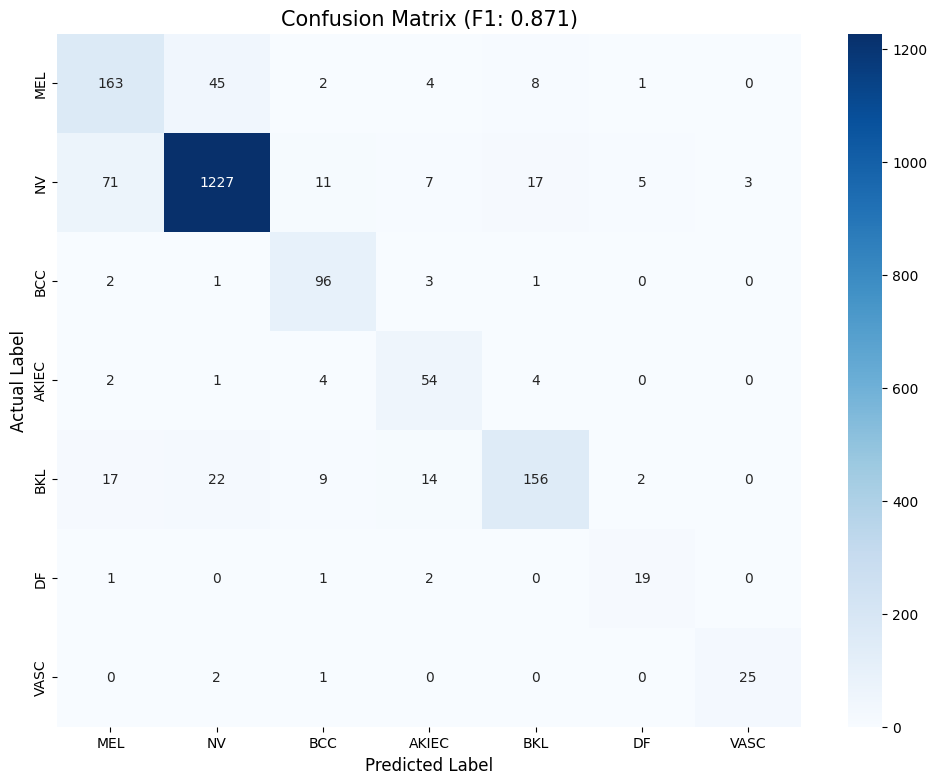

In [ ]:
model.load_state_dict(torch.load('Updated_best.pth'))
model.to(DEVICE)

target_class_names = list(label_cols) 

f1, auc = run_final_evaluation(model, val_loader, DEVICE, target_class_names)

In [ ]:
actual_model = model
feature_extractor = torch.nn.Sequential(*list(actual_model.children())[:-1])
feature_extractor.eval()

features_db = []
filenames_db = []

print("Building Feature Index (Fingerprinting Images)...")

with torch.no_grad():
    # We use the train_loader to build our 'reference library'
    for imgs, labels in tqdm(train_loader):
        imgs = imgs.to(DEVICE)
        
        # Get the 2048-dim vector from the GAP layer
        feats = feature_extractor(imgs)
        feats = feats.view(feats.size(0), -1) 
        
        features_db.append(feats.cpu().numpy())

final_features = np.vstack(features_db)
np.save('features.npy', final_features)

train_filenames = train_df['image'].values
np.save('filenames.npy', train_filenames)

print(f"Success! Saved {len(train_filenames)} image signatures.")

Building Feature Index (Fingerprinting Images)...


100%|██████████| 126/126 [02:11<00:00,  1.04s/it]

Success! Saved 8012 image signatures.


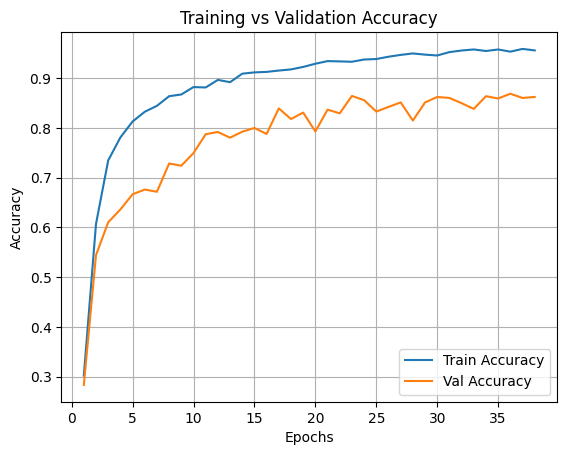

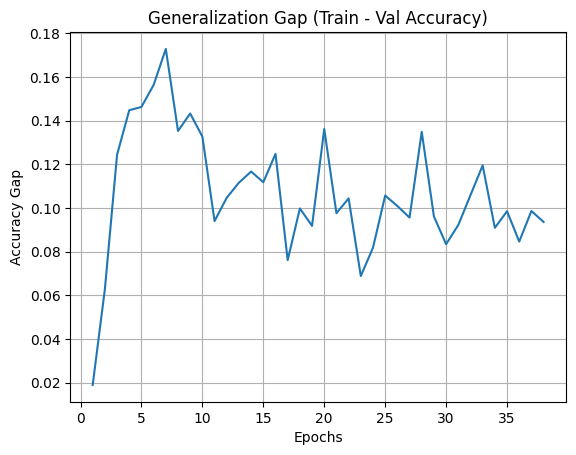

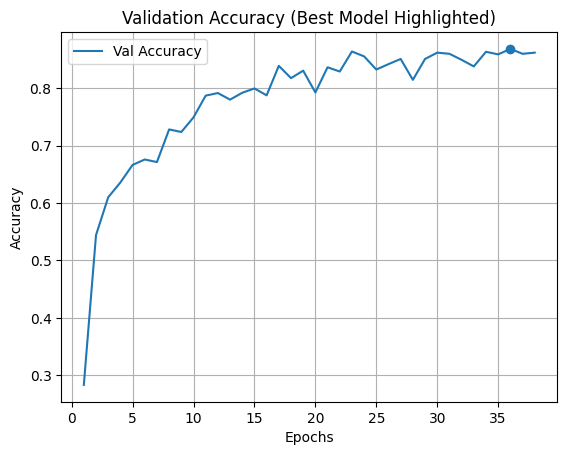

Best Epoch: 36
Best Validation Accuracy: 0.8687


In [3]:
import matplotlib.pyplot as plt

# ---------------------------
# Your data (from logs)
# ---------------------------
epochs = list(range(1, 41))

train_acc = [
0.3020, 0.6070, 0.7345, 0.7808, 0.8128, 0.8324,
0.8444, 0.8637, 0.8672, 0.8821, 0.8813, 0.8965,
0.8919, 0.9090, 0.9116, 0.9126, 0.9153, 0.9176,
0.9226, 0.9290, 0.9343, 0.9337, 0.9330, 0.9375,
0.9385, 0.9431, 0.9468, 0.9497, 0.9473, 0.9456,
0.9524, 0.9556, 0.9577, 0.9546, 0.9577, 0.9533,
0.9588, 0.9558, 0.9608, 0.9629
]

val_acc = [
0.2831, 0.5442, 0.6101, 0.6360, 0.6665, 0.6760,
0.6715, 0.7284, 0.7239, 0.7494, 0.7873, 0.7918,
0.7803, 0.7923, 0.7998, 0.7878, 0.8392, 0.8178,
0.8308, 0.7928, 0.8367, 0.8293, 0.8642, 0.8557,
0.8328, 0.8422, 0.8512, 0.8148, 0.8512, 0.8622,
0.8602, 0.8497, 0.8382, 0.8637, 0.8592, 0.8687,
0.8602, 0.8622
]

# ---------------------------
# FIX: align lengths safely
# ---------------------------
min_len = min(len(epochs), len(train_acc), len(val_acc))

epochs = epochs[:min_len]
train_acc = train_acc[:min_len]
val_acc = val_acc[:min_len]

# ---------------------------
# 1. Accuracy Curve
# ---------------------------
plt.figure()
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Val Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------
# 2. Generalization Gap
# ---------------------------
gap = [t - v for t, v in zip(train_acc, val_acc)]

plt.figure()
plt.plot(epochs, gap)

plt.title("Generalization Gap (Train - Val Accuracy)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy Gap")
plt.grid(True)
plt.show()

# ---------------------------
# 3. Best Validation Point
# ---------------------------
best_epoch = val_acc.index(max(val_acc)) + 1
best_val = max(val_acc)

plt.figure()
plt.plot(epochs, val_acc, label="Val Accuracy")
plt.scatter(best_epoch, best_val)

plt.title("Validation Accuracy (Best Model Highlighted)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("Best Epoch:", best_epoch)
print("Best Validation Accuracy:", best_val)